# Imports

In [1]:
import glob
import os
import random
import time

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import torch
from scipy.fft import fft, fftfreq, ifft, rfft, rfftfreq
from scipy.interpolate import PchipInterpolator
from scipy.io import wavfile
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from tqdm.notebook import tqdm

# Hyperparameters

In [2]:
DIR_PROJECT = "/home/mxadams/Dropbox/school_of_mines/CSCI575/project"
DIR_SRC = os.path.join(DIR_PROJECT, "CSCI575-project")
DIR_DATA = os.path.join(DIR_PROJECT, "Binary_Drone_Audio")
DIR_DRONE = os.path.join(DIR_DATA, "yes_drone")
DIR_UNKNOWN = os.path.join(DIR_DATA, "unknown")

In [3]:
RANDOM_SEED = 42
NUM_WORKERS = 8

## Data

In [4]:
NUM_FREQUENCIES = 8000  # Files have sample rate of 16000
TEST_FRAC = 0.2
SAMPLE_RATE = 16000

## Neural Network

In [5]:
LEARNING_RATE = 2 ** (-16)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2**8
MAX_NUM_EPOCHS = 2**8
TRAIN_CONVERGE_WINDOW = 2**3
TRAIN_CONVERGE_STD = 2 ** (-12)
PIN_MEMORY = True

## Random Forest

In [6]:
NUM_ESTIMATORS = 2**9
MAX_DEPTH = None
MIN_SAMPLES_LEAF = 1

# Data

https://www.kaggle.com/datasets/amineipad/drone-sound-audio-detection

## Exploration

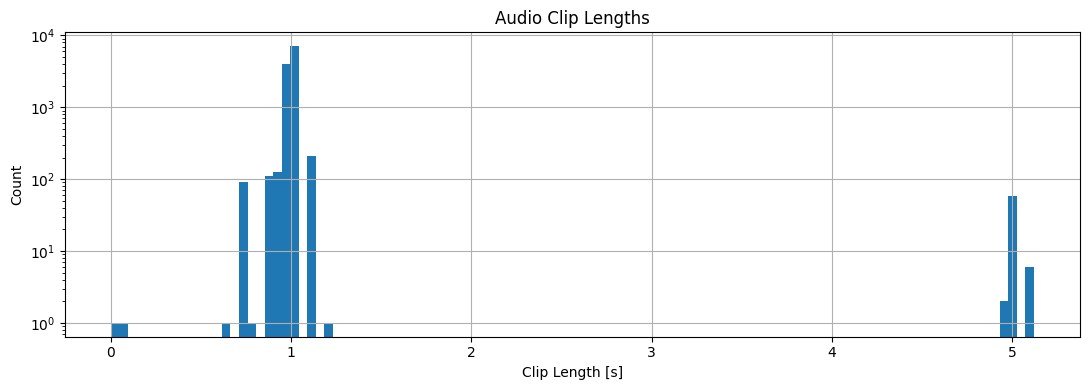

In [7]:
clip_lengths = np.array([])
for filename in os.listdir(DIR_DRONE):
    samplerate, data = wavfile.read(os.path.join(DIR_DRONE, filename))
    clip_lengths = np.append(clip_lengths, data.shape[0] / samplerate)
for filename in os.listdir(DIR_UNKNOWN):
    samplerate, data = wavfile.read(os.path.join(DIR_UNKNOWN, filename))
    clip_lengths = np.append(clip_lengths, data.shape[0] / samplerate)
plt.figure(figsize=(11, 4))
plt.hist(clip_lengths, bins=int(np.sqrt(len(clip_lengths))))
plt.title("Audio Clip Lengths")
plt.xlabel("Clip Length [s]")
plt.ylabel("Count")
plt.yscale("log")
plt.grid()
plt.tight_layout()

## Helper Functions

In [8]:
def extract_features(y, n_fft, sr=SAMPLE_RATE, min_samples=SAMPLE_RATE):
    if len(y) < min_samples:
        y = librosa.util.fix_length(y, size=min_samples)
    n_fft = 2 ** int(np.floor(np.log2(len(y))))
    hop_length = max(1, n_fft // 4)
    features = []
    S = np.abs(librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length, center=True))
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=20, n_fft=n_fft, hop_length=hop_length
    )
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    spec_centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(S=S, sr=sr, n_bands=6)
    for f in [spec_centroid, spec_bandwidth, spec_rolloff]:
        features.append(np.mean(f))
        features.append(np.std(f))
    features.extend(np.mean(spec_contrast, axis=1))
    features.extend(np.std(spec_contrast, axis=1))
    y_harm, y_perc = librosa.effects.hpss(y)
    features.append(np.sum(y_harm**2))
    features.append(np.sum(y_perc**2))
    zcr = librosa.feature.zero_crossing_rate(
        y, frame_length=n_fft, hop_length=hop_length
    )
    features.append(np.mean(zcr))
    features.append(np.std(zcr))
    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, tuning=0.0
    )
    features.extend(np.mean(chroma, axis=1))
    features.extend(np.std(chroma, axis=1))
    features = np.array(features, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    return features

In [9]:
def wav_to_data(filepath, num_features: int = NUM_FREQUENCIES):
    samplerate, data = wavfile.read(filepath)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data.astype(np.float32) / max_val
    else:
        data = data.astype(np.float32)
    data = data - np.mean(data)
    fft_val = rfft(data)
    fft_mag = np.abs(fft_val)
    fft_freq = rfftfreq(len(data), d=1.0 / samplerate)
    target_freq = np.arange(1, num_features)
    interp = PchipInterpolator(fft_freq, fft_mag, extrapolate=False)
    features = interp(target_freq)
    features = np.nan_to_num(features, nan=0.0)
    features = np.clip(features, 0.0, None)
    features = np.log1p(features)
    features = np.append(features, extract_features(data, len(fft_val)))
    return features.astype(np.float32)

In [10]:
def load_dataset(dir_drone, dir_unknown, num_features: int = NUM_FREQUENCIES):
    X = []
    y = []
    for label, folder in [(0, dir_drone), (1, dir_unknown)]:
        for filename in tqdm(sorted(os.listdir(folder))):
            if not filename.lower().endswith(".wav"):
                continue
            filepath = os.path.join(folder, filename)
            try:
                features = wav_to_data(filepath, num_features=num_features)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"Skipping {filepath}: {e}")
    X = np.stack(X)
    y = np.array(y, dtype=np.int64)
    return X, y

In [11]:
def seed_everything(seed: int = RANDOM_SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

## Data Setup

In [12]:
seed_everything(RANDOM_SEED)

In [13]:
data_load_time = time.perf_counter()
X_np, y_np = load_dataset(dir_drone=DIR_DRONE, dir_unknown=DIR_UNKNOWN)
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=TEST_FRAC, random_state=RANDOM_SEED, stratify=y_np
)
data_load_time = time.perf_counter() - data_load_time
print(f"Data Loaded in {data_load_time:.3f} seconds")

  0%|          | 0/1332 [00:00<?, ?it/s]

  0%|          | 0/10372 [00:00<?, ?it/s]

Data Loaded in 799.685 seconds


# Model Testing

## Neural Network

### Helper Functions

In [14]:
def evaluate_nn(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []
    all_drone_probs = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(logits, dim=1)
            drone_probs = probs[:, 0]
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())
            all_drone_probs.append(drone_probs.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_drone_probs = torch.cat(all_drone_probs).numpy()
    avg_loss = test_loss / len(test_loader.dataset)
    drone_true = (all_labels == 0).astype(int)
    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "drone_precision": precision_score(
            all_labels, all_preds, pos_label=0, zero_division=0
        ),
        "drone_recall": recall_score(
            all_labels, all_preds, pos_label=0, zero_division=0
        ),
        "drone_f1": f1_score(all_labels, all_preds, pos_label=0, zero_division=0),
        "drone_pr_auc": average_precision_score(drone_true, all_drone_probs),
        "confusion_matrix": confusion_matrix(all_labels, all_preds, labels=[0, 1]),
    }
    return metrics

### Model Definition

In [15]:
class NeuralNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(88 + NUM_FREQUENCIES - 1, 2**12),
            torch.nn.ReLU(),
            torch.nn.Linear(2**12, 2**9),
            torch.nn.ReLU(),
            torch.nn.Linear(2**9, 2**6),
            torch.nn.ReLU(),
            torch.nn.Linear(2**6, 2**3),
            torch.nn.ReLU(),
            torch.nn.Linear(2**3, 2),
        )

    def forward(self, x):
        return self.network(x)

### Model Setup

In [16]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)
)

In [17]:
generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
    generator=generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
    generator=generator,
)

In [19]:
seed_everything(RANDOM_SEED)

In [20]:
model = NeuralNet().to(DEVICE)
train_labels = torch.tensor(
    [train_dataset[i][1].item() for i in range(len(train_dataset))]
)
class_counts = torch.bincount(train_labels, minlength=2)
loss_class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
criterion = torch.nn.CrossEntropyLoss(weight=loss_class_weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Model Training

In [21]:
nn_train_time = time.perf_counter()
plot_data = {
    "epoch": np.array([0.0]),
    "train_loss": np.array([1.0]),
    "test_loss": np.array([1.0]),
    "accuracy": np.array([0.0]),
    "balanced_accuracy": np.array([0.0]),
    "precision": np.array([0.0]),
    "recall": np.array([0.0]),
    "f1-score": np.array([0.0]),
    "pr-auc": np.array([0.0]),
}
for epoch in range(MAX_NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in tqdm(train_loader):
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    avg_train_loss = total_loss / len(train_loader.dataset)
    metrics = evaluate_nn(
        model=model, test_loader=test_loader, criterion=criterion, device=DEVICE
    )
    plot_data["epoch"] = np.append(plot_data["epoch"], epoch + 1)
    plot_data["train_loss"] = np.append(plot_data["train_loss"], avg_train_loss)
    plot_data["test_loss"] = np.append(plot_data["test_loss"], metrics["loss"])
    plot_data["accuracy"] = np.append(plot_data["accuracy"], metrics["accuracy"])
    plot_data["balanced_accuracy"] = np.append(
        plot_data["balanced_accuracy"], metrics["balanced_accuracy"]
    )
    plot_data["precision"] = np.append(
        plot_data["precision"], metrics["drone_precision"]
    )
    plot_data["recall"] = np.append(plot_data["recall"], metrics["drone_recall"])
    plot_data["f1-score"] = np.append(plot_data["f1-score"], metrics["drone_f1"])
    plot_data["pr-auc"] = np.append(plot_data["pr-auc"], metrics["drone_pr_auc"])
    print(
        f"Epoch {str(int(plot_data["epoch"][-1])).rjust(len(str(MAX_NUM_EPOCHS)))}/{MAX_NUM_EPOCHS}  |  "
        f"Train loss: {plot_data["train_loss"][-1]:.4f}  |  "
        f"Test loss: {plot_data["test_loss"][-1]:.4f}  |  "
        f"Acc: {plot_data["accuracy"][-1]:.4f}  |  "
        f"Bal acc: {plot_data["balanced_accuracy"][-1]:.4f}  |  "
        f"Prec: {plot_data["precision"][-1]:.4f}  |  "
        f"Rec: {plot_data["recall"][-1]:.4f}  |  "
        f"F1: {plot_data["f1-score"][-1]:.4f}  |  "
        f"PR-AUC: {plot_data["pr-auc"][-1]:.4f}"
    )
    if len(plot_data["balanced_accuracy"]) > 2 * TRAIN_CONVERGE_WINDOW:
        train_converge_std = plot_data["balanced_accuracy"][
            len(plot_data["balanced_accuracy"]) - TRAIN_CONVERGE_WINDOW :
        ].std()
        train_converge_mean = plot_data["balanced_accuracy"][
            len(plot_data["balanced_accuracy"]) - TRAIN_CONVERGE_WINDOW :
        ].mean()
        if train_converge_std < TRAIN_CONVERGE_STD:
            print(
                f"Balanced Accuracy STD Converged to {train_converge_mean:.5f} +/- {train_converge_std:.5f}"
            )
            break
nn_train_time = time.perf_counter() - nn_train_time
print(f"Trained Neural Network in {nn_train_time:.3f} seconds")

  0%|          | 0/37 [00:00<?, ?it/s]

Epoch   1/256  |  Train loss: 0.4151  |  Test loss: 0.3284  |  Acc: 0.8197  |  Bal acc: 0.8590  |  Prec: 0.3781  |  Rec: 0.9098  |  F1: 0.5342  |  PR-AUC: 0.6695


  0%|          | 0/37 [00:00<?, ?it/s]

Epoch   2/256  |  Train loss: 0.2881  |  Test loss: 0.2862  |  Acc: 0.8210  |  Bal acc: 0.8728  |  Prec: 0.3828  |  Rec: 0.9398  |  F1: 0.5441  |  PR-AUC: 0.7378


  0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch  50/256  |  Train loss: 0.0140  |  Test loss: 0.0682  |  Acc: 0.9846  |  Bal acc: 0.9799  |  Prec: 0.8993  |  Rec: 0.9737  |  F1: 0.9350  |  PR-AUC: 0.9893


  0%|          | 0/37 [00:00<?, ?it/s]

Epoch  51/256  |  Train loss: 0.0133  |  Test loss: 0.0668  |  Acc: 0.9846  |  Bal acc: 0.9799  |  Prec: 0.8993  |  Rec: 0.9737  |  F1: 0.9350  |  PR-AUC: 0.9896


  0%|          | 0/37 [00:00<?, ?it/s]

Epoch  52/256  |  Train loss: 0.0127  |  Test loss: 0.0666  |  Acc: 0.9846  |  Bal acc: 0.9799  |  Prec: 0.8993  |  Rec: 0.9737  |  F1: 0.9350  |  PR-AUC: 0.9897
Balanced Accuracy STD Converged to 0.97973 +/- 0.00017
Trained Neural Network in 97.977 seconds


### Plot Model Metrics

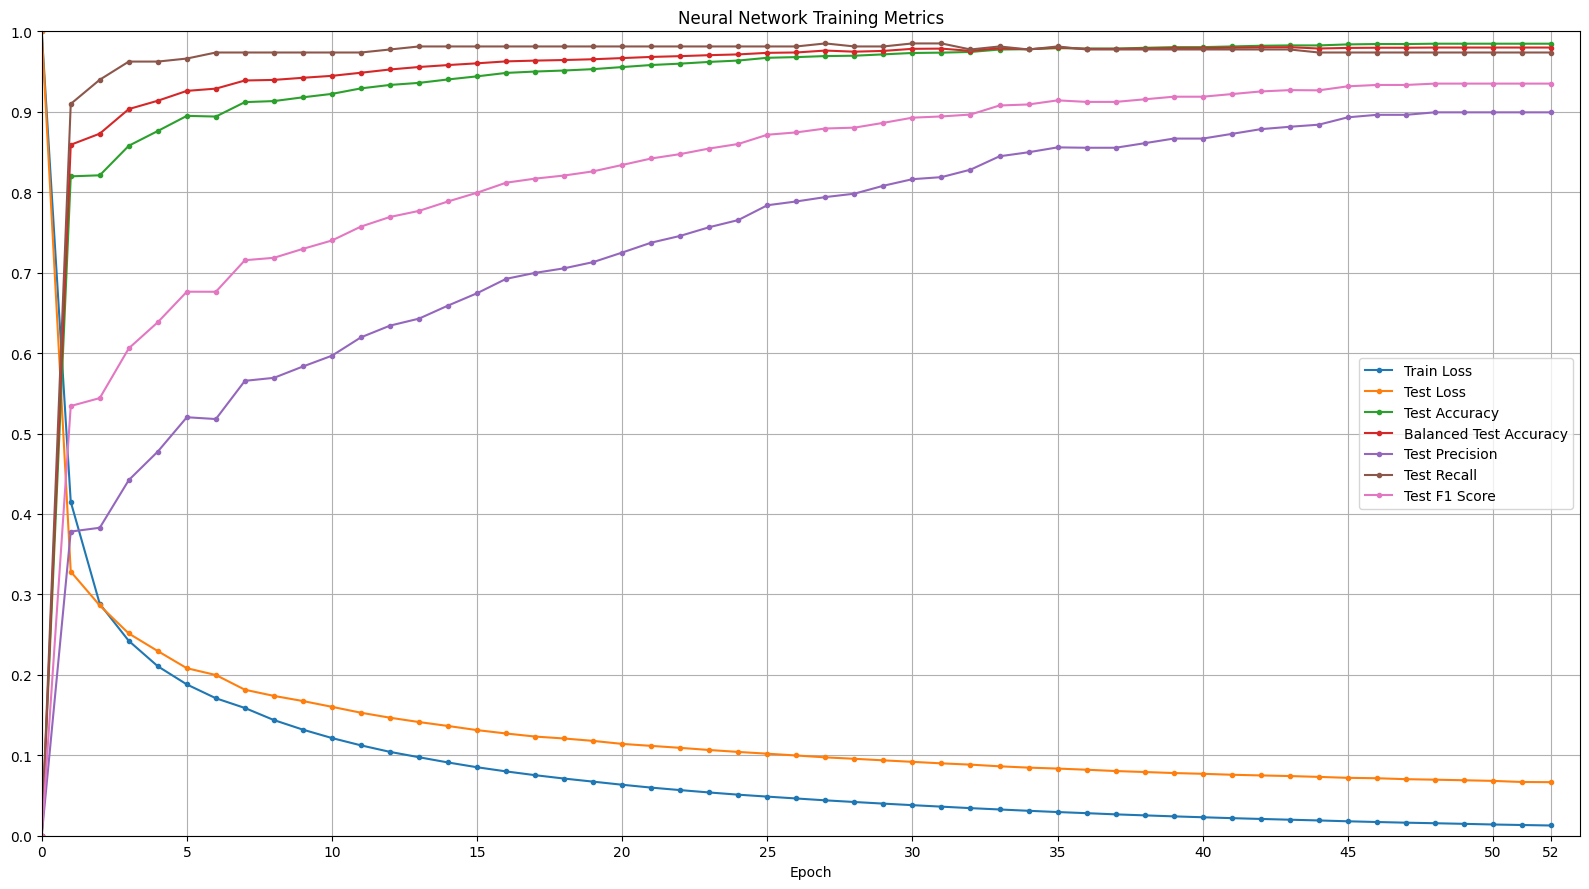

In [22]:
plt.figure(figsize=(16, 9))
plt.plot(plot_data["epoch"], plot_data["train_loss"], ".-", label="Train Loss")
plt.plot(plot_data["epoch"], plot_data["test_loss"], ".-", label="Test Loss")
plt.plot(plot_data["epoch"], plot_data["accuracy"], ".-", label="Test Accuracy")
plt.plot(
    plot_data["epoch"],
    plot_data["balanced_accuracy"],
    ".-",
    label="Balanced Test Accuracy",
)
plt.plot(plot_data["epoch"], plot_data["precision"], ".-", label="Test Precision")
plt.plot(plot_data["epoch"], plot_data["recall"], ".-", label="Test Recall")
plt.plot(plot_data["epoch"], plot_data["f1-score"], ".-", label="Test F1 Score")
# plt.plot(plot_data["epoch"], plot_data["pr-auc"], ".-", label="Average Test Precision")
plt.xlim([0, len(plot_data["epoch"])])
plt.ylim([0, 1])
plt.xticks(np.append(np.arange(0, len(plot_data["epoch"]), 5), plot_data["epoch"][-1]))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.legend()
plt.grid()
plt.title("Neural Network Training Metrics")
plt.xlabel("Epoch")
plt.tight_layout()
plt.savefig("nn_training.png", format="png")
plt.show()
plt.close()

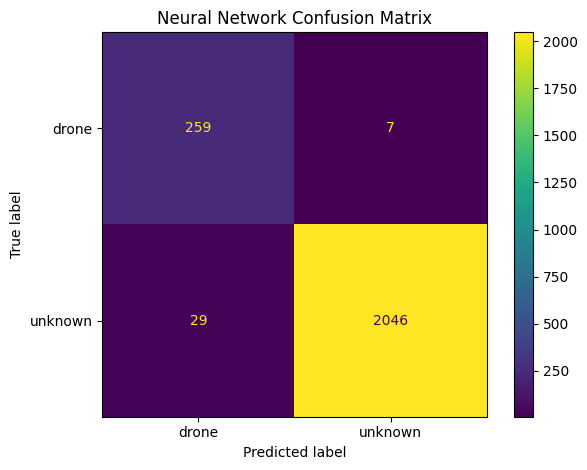

In [23]:
metrics = evaluate_nn(
    model=model, test_loader=test_loader, criterion=criterion, device=DEVICE
)
cm = metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["drone", "unknown"])
disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.savefig("nn_cm.png", format="png")
plt.show()
plt.close()

## Random Forest

### Model Fitting

In [24]:
seed_everything(RANDOM_SEED)

In [25]:
rf_train_time = time.perf_counter()
rf_model = RandomForestClassifier(
    n_estimators=NUM_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=NUM_WORKERS,
)
rf_model.fit(X_train, y_train)
rf_train_time = time.perf_counter() - rf_train_time
print(f"Trained Random Forest in {rf_train_time:.3f} seconds")

Trained Random Forest in 39.252 seconds


### Model Evaluation

In [26]:
rf_preds = rf_model.predict(X_test)
drone_class_index = np.where(rf_model.classes_ == 0)[0][0]
rf_drone_probs = rf_model.predict_proba(X_test)[:, drone_class_index]
rf_drone_true = (y_test == 0).astype(int)
rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, rf_preds),
    "precision": precision_score(y_test, rf_preds, pos_label=0, zero_division=0),
    "recall": recall_score(y_test, rf_preds, pos_label=0, zero_division=0),
    "f1-score": f1_score(y_test, rf_preds, pos_label=0, zero_division=0),
    "pr-auc": average_precision_score(rf_drone_true, rf_drone_probs),
    "confusion_matrix": confusion_matrix(y_test, rf_preds, labels=[0, 1]),
}
print(
    f"Acc: {rf_metrics["accuracy"]:.4f}  |  "
    f"Bal acc: {rf_metrics["balanced_accuracy"]:.4f}  |  "
    f"Prec: {rf_metrics["precision"]:.4f}  |  "
    f"Rec: {rf_metrics["recall"]:.4f}  |  "
    f"F1: {rf_metrics["f1-score"]:.4f}  |  "
    f"PR-AUC: {rf_metrics["pr-auc"]:.4f}"
)

Acc: 0.9782  |  Bal acc: 0.9074  |  Prec: 0.9909  |  Rec: 0.8158  |  F1: 0.8948  |  PR-AUC: 0.9778


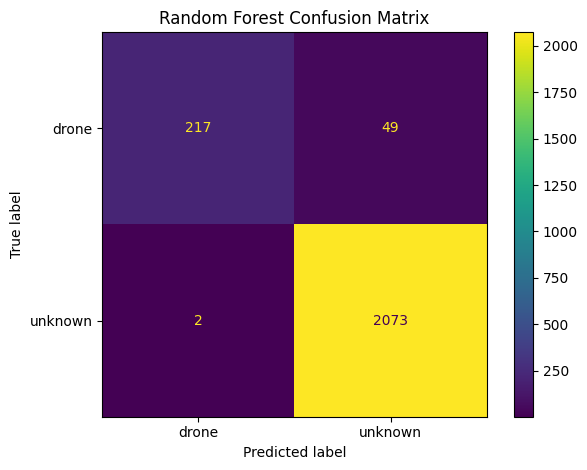

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, labels=[0, 1], display_labels=["drone", "unknown"]
)
plt.title("Random Forest Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.savefig("rf_cm.png", format="png")
plt.show()
plt.close()

## Other Models